# 04. LangGraph 입문 — 워크플로 만들기

LangGraph의 `StateGraph`로 노드와 엣지를 연결하는 워크플로를 만들어 봅니다.

## 학습 목표

- `StateGraph`로 상태 기반 그래프를 정의한다
- 노드(함수)를 등록하고 엣지로 연결한다
- `compile()` → `invoke()`로 그래프를 실행한다

## 4.1 환경 설정

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

from langchain_openai import ChatOpenAI
model = ChatOpenAI(model="gpt-5.4")
print("\u2713 모델 준비 완료")

✓ 모델 준비 완료


In [2]:
# Observability 설정 (선택) - LangSmith 또는 Langfuse
# .env에 키를 설정하거나, 아래 주석을 해제하여 직접 입력하세요.
# os.environ["LANGFUSE_SECRET_KEY"] = "sk-lf-..."
# os.environ["LANGFUSE_PUBLIC_KEY"] = "pk-lf-..."
# os.environ["LANGFUSE_HOST"] = "https://lf.ddok.ai"
import os

# LangSmith: LANGSMITH_TRACING=true 시 자동 활성화 (코드 수정 불필요)
if os.environ.get("LANGSMITH_TRACING", "").lower() == "true":
    os.environ.setdefault("LANGCHAIN_TRACING_V2", "true")
    os.environ.setdefault("LANGCHAIN_API_KEY", os.environ.get("LANGSMITH_API_KEY", ""))
    os.environ.setdefault("LANGCHAIN_PROJECT", os.environ.get("LANGSMITH_PROJECT", "default"))
    print(f"LangSmith tracing ON \u2014 project: {os.environ['LANGCHAIN_PROJECT']}")

# Langfuse: invoke/stream 호출 시 config={"callbacks": [langfuse_handler]} 전달
langfuse_handler = None
if os.environ.get("LANGFUSE_SECRET_KEY"):
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()
    print(f"Langfuse tracing ON \u2014 {os.environ.get('LANGFUSE_HOST', '')}")

# Langfuse config: pass to invoke/stream/batch calls
lf_config = {"callbacks": [langfuse_handler]} if langfuse_handler else {}


LangSmith tracing ON — project: day1-labs-test


## 4.2 첫 번째 그래프

LangGraph의 기본 흐름은 5단계입니다:

```
StateGraph(State) → add_node() → add_edge() → compile() → invoke()
```

**StateGraph의 핵심 개념:**

LangGraph는 에이전트 워크플로를 **그래프**로 모델링하며, 세 가지 기본 구성 요소를 사용합니다:

1. **State(상태)**: 애플리케이션의 현재 스냅샷을 나타내는 공유 데이터 구조입니다. 보통 `TypedDict`나 Pydantic 모델로 정의합니다.
2. **Node(노드)**: 상태를 받아 연산을 수행하고 업데이트된 상태를 반환하는 함수입니다. 즉, **노드가 실제 작업을 수행**합니다.
3. **Edge(엣지)**: 현재 상태를 기반으로 다음에 실행할 노드를 결정합니다. 즉, **엣지가 다음 할 일을 지시**합니다.

`StateGraph`는 주요 그래프 클래스로, 사용자 정의 State 객체를 매개변수로 받습니다. 그래프는 반드시 `.compile()` 메서드를 통해 컴파일한 후 사용해야 하며, 컴파일 시 구조 검증이 수행됩니다.

아래 예제는 텍스트의 단어 수를 세는 간단한 1노드 그래프입니다.

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class State(TypedDict):
    text: str
    word_count: int

def count_words(state: State) -> dict:
    return {"word_count": len(state["text"].split())}

builder = StateGraph(State)
builder.add_node("counter", count_words)
builder.add_edge(START, "counter")
builder.add_edge("counter", END)

graph = builder.compile()
result = graph.invoke({"text": "LangGraph는 강력한 프레임워크입니다"}, config=lf_config)
print(f"텍스트: {result['text']}")
print(f"단어 수: {result['word_count']}")

텍스트: LangGraph는 강력한 프레임워크입니다
단어 수: 3


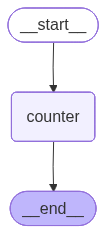

In [4]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## 4.3 2노드 그래프

두 개의 노드를 순서대로 연결합니다.
첫 번째 노드가 텍스트를 대문자로 변환하고, 두 번째 노드가 단어 수를 셉니다.

```
START → uppercase → counter → END
```

In [5]:
class State2(TypedDict):
    text: str
    word_count: int

def to_upper(state: State2) -> dict:
    return {"text": state["text"].upper()}

def count(state: State2) -> dict:
    return {"word_count": len(state["text"].split())}

builder = StateGraph(State2)
builder.add_node("uppercase", to_upper)
builder.add_node("counter", count)
builder.add_edge(START, "uppercase")
builder.add_edge("uppercase", "counter")
builder.add_edge("counter", END)

graph = builder.compile()
result = graph.invoke({"text": "안녕하세요 langgraph 세계"}, config=lf_config)
print(f"변환된 텍스트: {result['text']}")
print(f"단어 수: {result['word_count']}")

변환된 텍스트: 안녕하세요 LANGGRAPH 세계
단어 수: 3


In [8]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

class State2_1(BaseModel):
    text: str
    word_count: int = 0   # 시작 시점엔 모르니 기본값

def to_upper(state: State2_1) -> dict:
    return {"text": state.text.upper()}   # dict가 아니라 속성 접근

def count(state: State2_1) -> dict:
    return {"word_count": len(state.text.split())}

builder = StateGraph(State2_1)
builder.add_node("uppercase", to_upper)
builder.add_node("counter", count)
builder.add_edge(START, "uppercase")
builder.add_edge("uppercase", "counter")
builder.add_edge("counter", END)

graph = builder.compile()

# ✅ 정상 케이스
result = graph.invoke({"text": "안녕하세요 langgraph 세계"}, config=lf_config)
print(f"변환된 텍스트: {result['text']}")
print(f"단어 수: {result['word_count']}")


변환된 텍스트: 안녕하세요 LANGGRAPH 세계
단어 수: 3


In [9]:
from pydantic import ValidationError

try:
    graph.invoke({"text": 12345}, config=lf_config)   # str인데 int
except ValidationError as e:
    print("입력 검증 실패:")
    print(e)

입력 검증 실패:
1 validation error for State2_1
text
  Input should be a valid string [type=string_type, input_value=12345, input_type=int]
    For further information visit https://errors.pydantic.dev/2.12/v/string_type


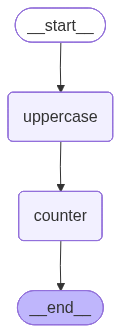

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

## 4.4 LLM을 노드로 사용하기

`MessagesState`를 사용하면 LLM 대화를 그래프로 구성할 수 있습니다.

**MessagesState란?**

`MessagesState`는 LangGraph가 제공하는 **사전 정의 상태 클래스**로, `messages`라는 단일 키를 가지며 `add_messages`를 리듀서로 사용합니다. 내부적으로 다음과 같이 정의되어 있습니다:

```python
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]
```

`add_messages` 리듀서는 메시지 ID를 추적하여 중복 없이 메시지를 누적하고, JSON을 LangChain Message 객체로 자동 역직렬화합니다. 추가 필드(문서, 메타데이터 등)가 필요하면 `MessagesState`를 서브클래싱하면 됩니다.

**노드의 구조:**

노드는 현재 상태(`state`)를 받아 상태 업데이트를 반환하는 일반 Python 함수(동기/비동기)입니다. LangGraph는 노드를 자동으로 `RunnableLambda` 객체로 변환하여 배치 처리, 비동기 지원, 네이티브 트레이싱 기능을 추가합니다.

In [7]:
from langgraph.graph import MessagesState
from langchain.messages import HumanMessage

def chatbot(state: MessagesState) -> dict:
    return {"messages": [model.invoke(state["messages"], config=lf_config)]}

builder = StateGraph(MessagesState)
builder.add_node("chatbot", chatbot)
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()
result = graph.invoke({"messages": [HumanMessage(content="2+2는 얼마인가요?")]}, config=lf_config)
print("응답:", result["messages"][-1].content)

응답: 2+2는 4입니다.


## 요약

| 핵심 API | 역할 |
|---|---|
| `StateGraph(State)` | 상태 스키마로 그래프 빌더 생성 |
| `add_node()` | 노드(함수) 등록 |
| `add_edge()` | 노드 간 연결 |
| `compile()` | 실행 가능한 그래프 생성 |
| `invoke()` | 그래프 실행 |

### 다음 단계
→ **[05_deep_agents_basics.ipynb](./05_deep_agents_basics.ipynb)**: Deep Agents로 올인원 에이전트를 만듭니다.